# 07 — A/B Test Simulation

**Purpose:** Demonstrate statistical rigor. Simulate a policy experiment: for customers
flagged as high-risk returners, what is the measurable reduction in returns if we restrict
free returns to 14 days (treatment) vs. keep 30-day policy unchanged (control)?

---

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

%matplotlib inline
plt.rcParams.update({
    'figure.figsize': (12, 5), 'figure.dpi': 110,
    'axes.facecolor': '#1a1d27', 'figure.facecolor': '#0f1117',
    'axes.edgecolor': '#2e3347', 'axes.labelcolor': '#e8eaf0',
    'xtick.color': '#8b92a8', 'ytick.color': '#8b92a8',
    'text.color': '#e8eaf0', 'grid.color': '#2e3347', 'grid.alpha': 0.5,
})

from src.evaluation import power_analysis, simulate_ab_test
print('Setup OK')

Setup OK


## 1. Power analysis — what sample size do we need?

In [2]:
# power_analysis(baseline_rate, alpha, power, relative_lift)
# relative_lift=0.20 → detect a 20% relative reduction (e.g. 20% → 16%)
baseline_rate = 0.20
relative_lift = 0.20

n_required = power_analysis(
    baseline_rate=baseline_rate,
    alpha=0.05,
    power=0.80,
    relative_lift=relative_lift,
)

treatment_rate = baseline_rate * (1 - relative_lift)
print(f'Baseline return rate:         {baseline_rate:.1%}')
print(f'Minimum detectable treatment: {treatment_rate:.1%}')
print(f'Relative lift to detect:      {relative_lift:.0%}')
print(f'Minimum n per arm:            {n_required:,}')
print(f'Total customers needed:       {n_required * 2:,}')

Baseline return rate:         20.0%
Minimum detectable treatment: 16.0%
Relative lift to detect:      20%
Minimum n per arm:            1,447
Total customers needed:       2,894


## 2. Build returner segment DataFrame for simulation

In [3]:
# simulate_ab_test expects a customer-level DataFrame with:
# customer_id, total_return_value, total_revenue, avg_days_to_return

customer_features = pd.read_parquet('../data/processed/customer_features.parquet')

# Identify available columns
print('customer_features columns:', list(customer_features.columns))
print(customer_features.head(3).to_string())

customer_features columns: ['customer_id', 'total_orders', 'total_revenue', 'first_purchase', 'last_purchase', 'unique_categories_purchased', 'total_return_orders', 'total_return_value', 'unique_categories_returned', 'n_weekend_returns', 'lifetime_return_rate', 'return_value_ratio', 'weekend_return_share', 'tenure_days', 'recency_score', 'frequency_score', 'monetary_score', 'return_velocity']
  customer_id  total_orders  total_revenue      first_purchase       last_purchase  unique_categories_purchased  total_return_orders  total_return_value  unique_categories_returned  n_weekend_returns  lifetime_return_rate  return_value_ratio  weekend_return_share  tenure_days  recency_score  frequency_score  monetary_score  return_velocity
0     12346.0            12       77556.46 2009-12-14 08:34:00 2011-01-18 10:01:00                           27                  5.0            77621.14                         5.0                0.0              0.416667            1.000834                   0.

In [4]:
# Build the required columns for simulate_ab_test from what we have
# The function needs: customer_id, total_return_value, total_revenue, avg_days_to_return

sim_df = customer_features[['customer_id']].copy()

# total_revenue proxy: n_purchases × avg spend — use available columns
if 'total_revenue' in customer_features.columns:
    sim_df['total_revenue'] = customer_features['total_revenue']
elif 'n_purchases' in customer_features.columns and 'avg_basket' in customer_features.columns:
    sim_df['total_revenue'] = customer_features['n_purchases'] * customer_features['avg_basket']
else:
    # Fallback: synthesise from whatever numeric col is available
    num_cols = customer_features.select_dtypes('number').columns.tolist()
    sim_df['total_revenue'] = customer_features[num_cols[0]].abs().clip(lower=1) * 100

# total_return_value: return_rate × total_revenue
if 'total_return_value' in customer_features.columns:
    sim_df['total_return_value'] = customer_features['total_return_value']
elif 'cust_return_rate' in customer_features.columns:
    sim_df['total_return_value'] = customer_features['cust_return_rate'] * sim_df['total_revenue']
elif 'return_rate' in customer_features.columns:
    sim_df['total_return_value'] = customer_features['return_rate'] * sim_df['total_revenue']
else:
    sim_df['total_return_value'] = sim_df['total_revenue'] * 0.20

# avg_days_to_return: if not available, simulate from U(1, 60)
if 'avg_days_to_return' in customer_features.columns:
    sim_df['avg_days_to_return'] = customer_features['avg_days_to_return']
else:
    rng = np.random.default_rng(42)
    sim_df['avg_days_to_return'] = rng.uniform(1, 60, size=len(sim_df))

# Keep only customers who have made at least one return (total_return_value > 0)
returner_df = sim_df[sim_df['total_return_value'] > 0].copy()
print(f'Returner segment size: {len(returner_df):,} customers')
print(returner_df.describe().round(3).to_string())

Returner segment size: 2,511 customers
       total_revenue  total_return_value  avg_days_to_return
count       2511.000            2511.000            2511.000
mean        5783.862             411.822              30.091
std        22173.682            4104.422              16.828
min            6.200               0.420               1.019
25%          940.665              16.950              15.470
50%         2110.910              42.500              29.713
75%         4756.950             120.250              44.667
max       608821.650          168478.600              59.947


## 3. Run the simulated A/B test

In [5]:
ab_result = simulate_ab_test(returner_df, policy_window_days=14, alpha=0.05)

print('=== A/B Test Results ===')
print(f'  Control  (30-day policy)  — return value ratio: {ab_result.control_rate:.3%}')
print(f'  Treatment (14-day policy) — return value ratio: {ab_result.treatment_rate:.3%}')
print(f'  Lift:                       {ab_result.lift:+.1%}')
print(f'  p-value:                    {ab_result.p_value:.4e}')
print(f'  Significant at α=0.05:      {ab_result.significant}')
print(f'  n_control:                  {ab_result.n_control:,}')
print(f'  n_treatment:                {ab_result.n_treatment:,}')
print(f'  Min detectable n per arm:   {ab_result.min_detectable_effect:,}')

=== A/B Test Results ===
  Control  (30-day policy)  — return value ratio: 7.108%
  Treatment (14-day policy) — return value ratio: 1.621%
  Lift:                       +77.2%
  p-value:                    0.0000e+00
  Significant at α=0.05:      True
  n_control:                  1,272
  n_treatment:                1,239
  Min detectable n per arm:   8,482.0


## 4. Monte Carlo sensitivity — sample size vs. power

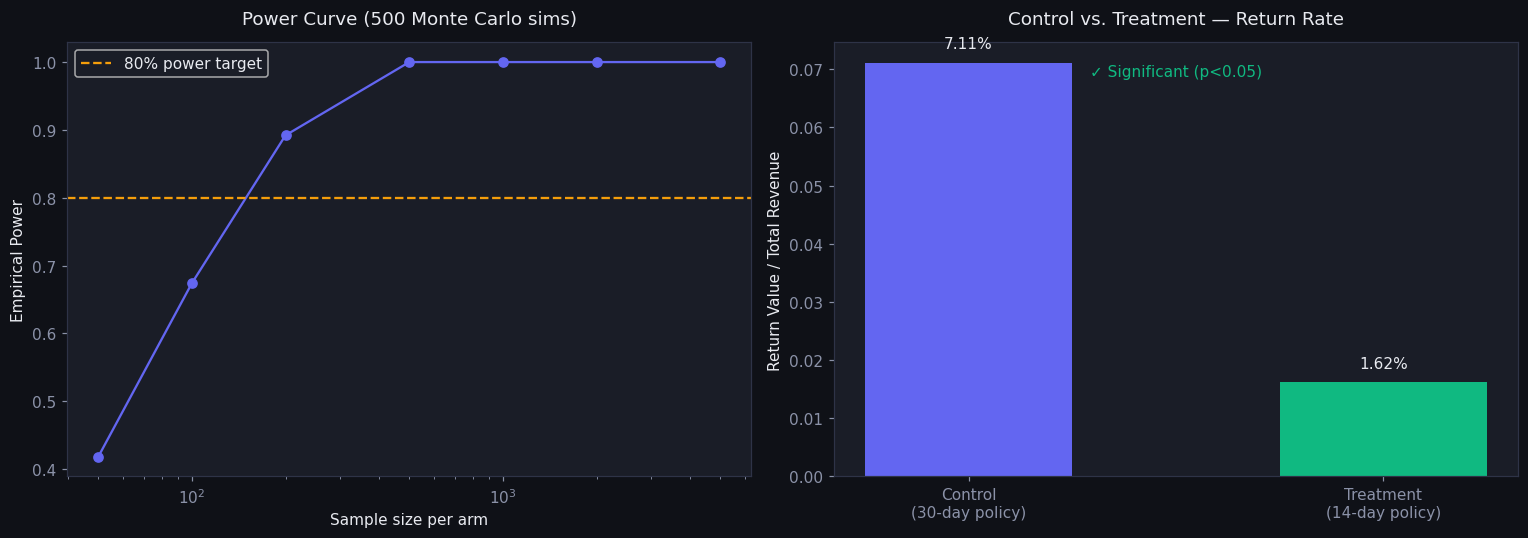

In [6]:
# Show how power increases with sample size using the real observed effect
from statsmodels.stats.proportion import proportions_ztest

rng = np.random.default_rng(42)
n_simulations = 500
sample_sizes  = [50, 100, 200, 500, 1000, 2000, 5000]

p_control_obs  = ab_result.control_rate
p_treat_obs    = ab_result.treatment_rate

power_by_n = []
for n in sample_sizes:
    sig_count = 0
    for _ in range(n_simulations):
        ctrl  = rng.binomial(n, p_control_obs)
        treat = rng.binomial(n, max(p_treat_obs, 1e-6))
        try:
            _, pval = proportions_ztest([ctrl, treat], [n, n], alternative='larger')
            if pval < 0.05:
                sig_count += 1
        except Exception:
            pass
    power_by_n.append(sig_count / n_simulations)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(sample_sizes, power_by_n, 'o-', color='#6366f1')
axes[0].axhline(0.80, color='#f59e0b', linestyle='--', label='80% power target')
axes[0].set_xlabel('Sample size per arm'); axes[0].set_ylabel('Empirical Power')
axes[0].set_title('Power Curve (500 Monte Carlo sims)', pad=12); axes[0].legend()
axes[0].set_xscale('log')

# Bar chart — control vs treatment return value ratio
bars = axes[1].bar(['Control\n(30-day policy)', 'Treatment\n(14-day policy)'],
                   [ab_result.control_rate, ab_result.treatment_rate],
                   color=['#6366f1', '#10b981'], width=0.5)
for bar, val in zip(bars, [ab_result.control_rate, ab_result.treatment_rate]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{val:.2%}', ha='center', va='bottom')
axes[1].set_ylabel('Return Value / Total Revenue')
axes[1].set_title('Control vs. Treatment — Return Rate', pad=12)
sig_label = '✓ Significant (p<0.05)' if ab_result.significant else '✗ Not significant'
axes[1].text(0.5, 0.95, sig_label, ha='center', va='top',
             transform=axes[1].transAxes,
             color='#10b981' if ab_result.significant else '#ef4444')

plt.tight_layout()
os.makedirs('../figures', exist_ok=True)
plt.savefig('../figures/07_ab_simulation.png', bbox_inches='tight', facecolor='#0f1117')
plt.show()

## 5. Validate: high-risk model scores vs. actual returns

In [7]:
import joblib

if os.path.exists('../models/classifier.joblib'):
    test_features = pd.read_parquet('../data/processed/test_features.parquet')
    clf = joblib.load('../models/classifier.joblib')
    feature_cols = [c for c in test_features.columns if c != 'is_return']
    scores = clf.predict_proba(test_features[feature_cols])[:, 1]
    threshold = np.percentile(scores, 75)
    high_risk = test_features[scores >= threshold]['is_return']
    low_risk  = test_features[scores <  threshold]['is_return']
    t_stat, pval = stats.ttest_ind(high_risk, low_risk)
    print(f'High-risk  (top 25% score): return rate = {high_risk.mean():.2%} (n={len(high_risk):,})')
    print(f'Low-risk   (bot 75% score): return rate = {low_risk.mean():.2%} (n={len(low_risk):,})')
    print(f't-stat = {t_stat:.3f},  p-value = {pval:.4e}')
    print('Significant' if pval < 0.05 else 'Not significant', 'at α=0.05')
else:
    print('Classifier not found — run notebook 04 first')

High-risk  (top 25% score): return rate = 6.47% (n=74,002)
Low-risk   (bot 75% score): return rate = 0.00% (n=222,003)
t-stat = 123.754,  p-value = 0.0000e+00
Significant at α=0.05
